# Exploratory Data Analysis (EDA) - [Titanic - Machine Learning from Disaster]

**Objective**: Predict passenger survival on the Titanic using machine learning through cleaning, and feature analysis, and model training

**Data Source**: [Kaggle: Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

## Packages installation and libraries importation

In [1]:
pip install pandas numpy matplotlib torch scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Some common libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Data

In [3]:
df = pd.read_csv('../data/raw/train.csv')
print(f"Initial dataset shape: {df.shape}")
print(df.shape)
df.head()

Initial dataset shape: (891, 12)
(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data overview

In [4]:
print("Data info:")
df.info()
df.describe()
print("\nMissing values per column:")
print(df.isna().sum())
print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          

- Pclass: A proxy for socio-economic status (SES)
    + 1st = Upper
    + 2nd = Middle
    + 3rd = Lower

- Age: Age is fractional if less than 1, it in the form of x.5 if estimated

- Sibsp: The dataset defines family relations
    + Sibling = brother, sister, stepbrother, stepsister
    + Spouse = husband, wife (mistresses and fiancés were ignored)

- Parch: The dataset defines family relations in this way...
    + Parent = mother, father
    + Child = daughter, son, stepdaughter, stepson
    + Some children travelled only with a nanny, therefore parch=0 for them.

In [5]:
# Fill missing ages and embarks with median, and most frequent port based on Pclass and Sex
df.fillna({'Age': df.groupby(['Pclass', 'Sex'])['Age'].transform('median')}, inplace=True)
df.fillna({'Embarked': df.groupby(['Pclass', 'Sex'])['Embarked'].transform(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')}, inplace=True)   

77% the values in Cabin are missing, and PassengerId is irrelevant for analysis

In [6]:
df = df.drop(['PassengerId', 'Cabin'], axis=1)

## Data transformation and encoding

In [7]:
# Change the keys to better readable ones
df['Embarked'] = df['Embarked'].replace(['C','S','Q'], ['Cherbourg','Southampton','Queenstown'])
df['Survived'] = df['Survived'].replace([0, 1], ['No', 'Yes'])
df['Pclass'] = df['Pclass'].replace([1, 2, 3], ['Upper', 'Middle', 'Lower'])

df[['Embarked', 'Survived', 'Pclass']] = df[['Embarked', 'Survived', 'Pclass']]

In [8]:
# Convert age values into ordered age groups
df['Age'] = pd.cut(df['Age'], bins=[0, 5, 12, 18, 65, 150], labels=['Infant', 'Child', 'Teenager', 'Adult', 'Senior'])
# Combine siblings and parch to represent the total family members all board
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['Age'] = df['Age']
df['FamilySize'] = df['FamilySize'].astype('int64')
df['Sex'] = df['Sex']

df = df.drop(columns=['SibSp', 'Parch'], axis=1)

In [9]:
def extract_title_and_last_name(name: str):
    if not name or not name.strip():
        return None, None
    
    parts = name.split(', ')
    
    last_name = parts[0] if len(parts) > 0 else None  # Remove last char
    title = parts[1].split('. ')[0] if len(parts) > 1 else None
    
    return title, last_name

In [10]:
df[['Title', 'LastName']] = df['Name'].apply(lambda x: pd.Series(extract_title_and_last_name(x)))

df.head()

,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,FamilySize,Title,LastName
0,No,Lower,"Braund, Mr. Owen Harris",male,Adult,A/5 21171,7.2500,Southampton,2,Mr,Braund
1,Yes,Upper,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,Adult,PC 17599,71.2833,Cherbourg,2,Mrs,Cumings
2,Yes,Lower,"Heikkinen, Miss. Laina",female,Adult,STON/O2. 3101282,7.9250,Southampton,1,Miss,Heikkinen
3,Yes,Upper,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,Adult,113803,53.1000,Southampton,2,Mrs,Futrelle
4,No,Lower,"Allen, Mr. William Henry",male,Adult,373450,8.0500,Southampton,1,Mr,Allen


In [11]:
categorical_df = df.loc[:, df.nunique() <= 10]
print("Categorical features: ", categorical_df.columns.values)

numerical_df = df.select_dtypes(include='number')
print("Numerical features: ", numerical_df.columns.values)

str_df = df.select_dtypes(include='object')
print("String features: ", str_df.columns.values)

Categorical features:  ['Survived' 'Pclass' 'Sex' 'Age' 'Embarked' 'FamilySize']
Numerical features:  ['Fare' 'FamilySize']
String features:  ['Survived' 'Pclass' 'Name' 'Sex' 'Ticket' 'Embarked' 'Title' 'LastName']


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    object  
 1   Pclass      891 non-null    object  
 2   Name        891 non-null    object  
 3   Sex         891 non-null    object  
 4   Age         891 non-null    category
 5   Ticket      891 non-null    object  
 6   Fare        891 non-null    float64 
 7   Embarked    891 non-null    object  
 8   FamilySize  891 non-null    int64   
 9   Title       891 non-null    object  
 10  LastName    891 non-null    object  
dtypes: category(1), float64(1), int64(1), object(8)
memory usage: 70.8+ KB


## Univariate Analysis

Mean: 32.204207968574636 
Median: 14.4542


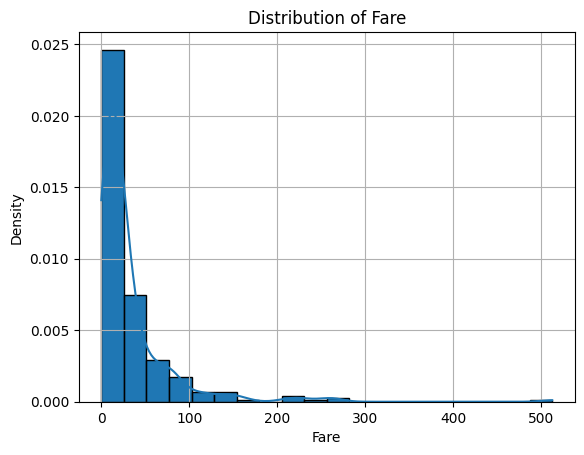

Mean: 1.904601571268238 
Median: 1.0


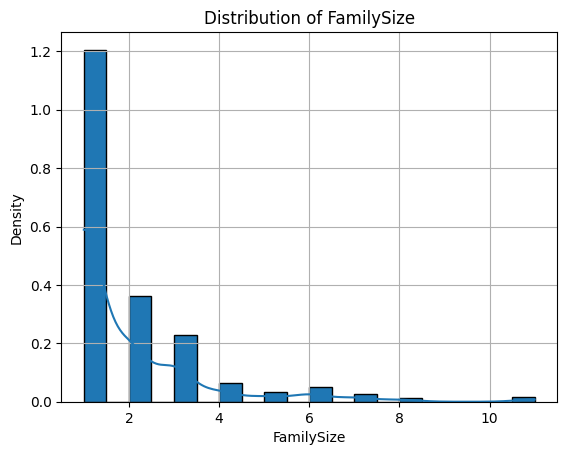

In [13]:
import seaborn as sns
for col in numerical_df.columns:
    numerical_df[col].dropna().hist(bins=20, density=True)
    sns.histplot(numerical_df[col], bins=20, kde=True, stat="density")
    print(f'Mean: {numerical_df[col].mean()} \nMedian: {numerical_df[col].median()}')
    plt.title(f'Distribution of {col}')
    plt.show()

In [14]:
def group_by_col_and_plot(df, col):
    gr = df.groupby(col, observed=False).size().to_frame(name='Count')
    gr['Ratio'] = np.round(gr['Count'] / gr['Count'].sum() * 100, 0)
    
    print(f'Total number of {col}: {gr["Count"].sum()}')
    
    colors = sns.color_palette(n_colors=len(gr))
    
    # Create subplots
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar chart
    gr['Count'].plot(kind='bar', ax=ax1, color=colors, title=f'{col} Counts')
    ax1.set_xlabel('')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=0)
    
    # Pie chart
    gr['Ratio'].plot(kind='pie', ax=ax2, colors=colors, title=f'{col} Ratio', autopct='%1.1f%%', ylabel='')   

    plt.tight_layout()
    plt.show()
    

Total number of Survived: 891


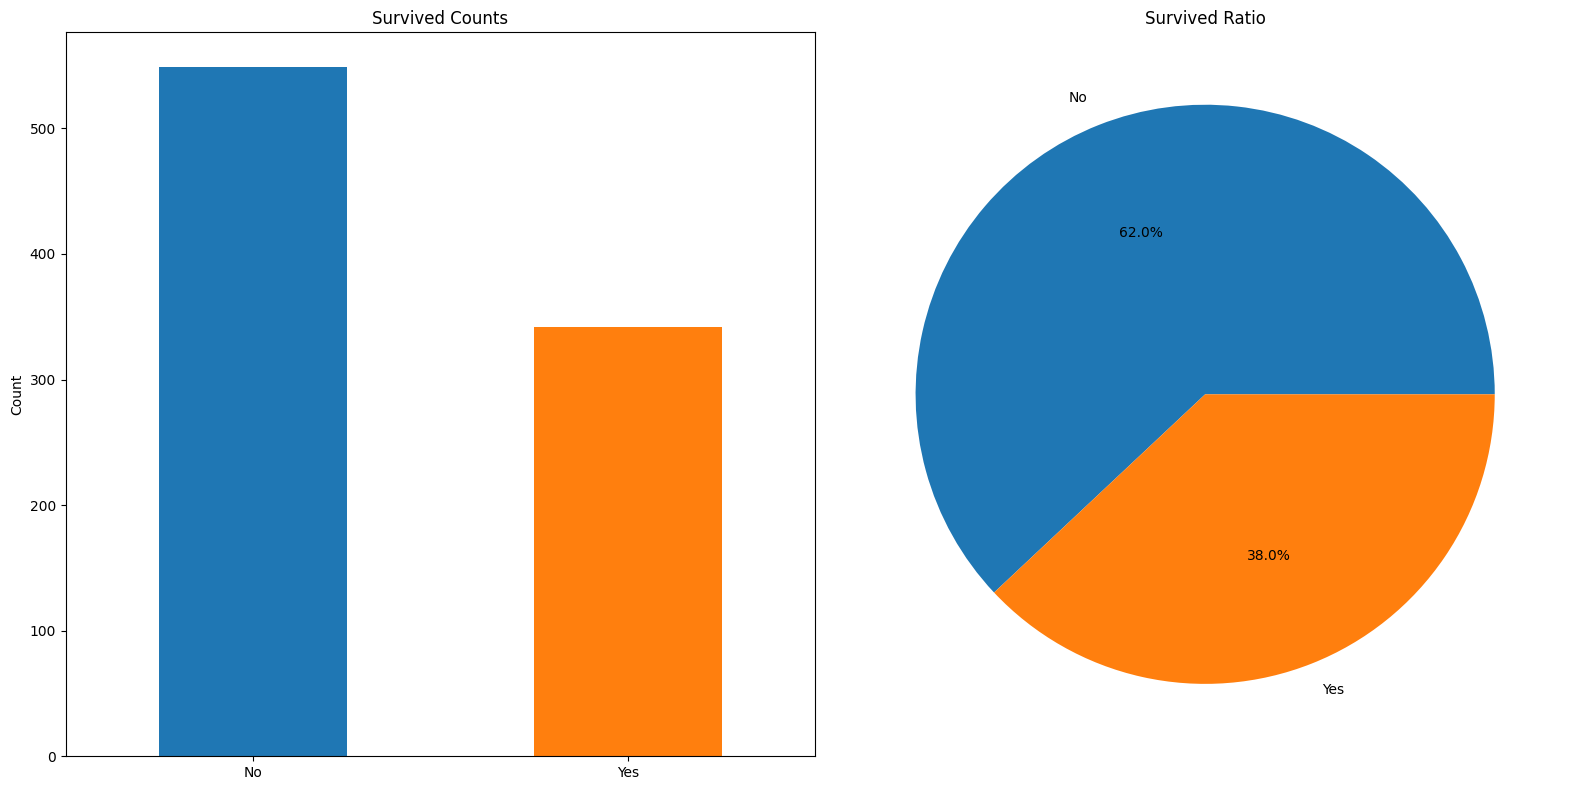

Total number of Pclass: 891


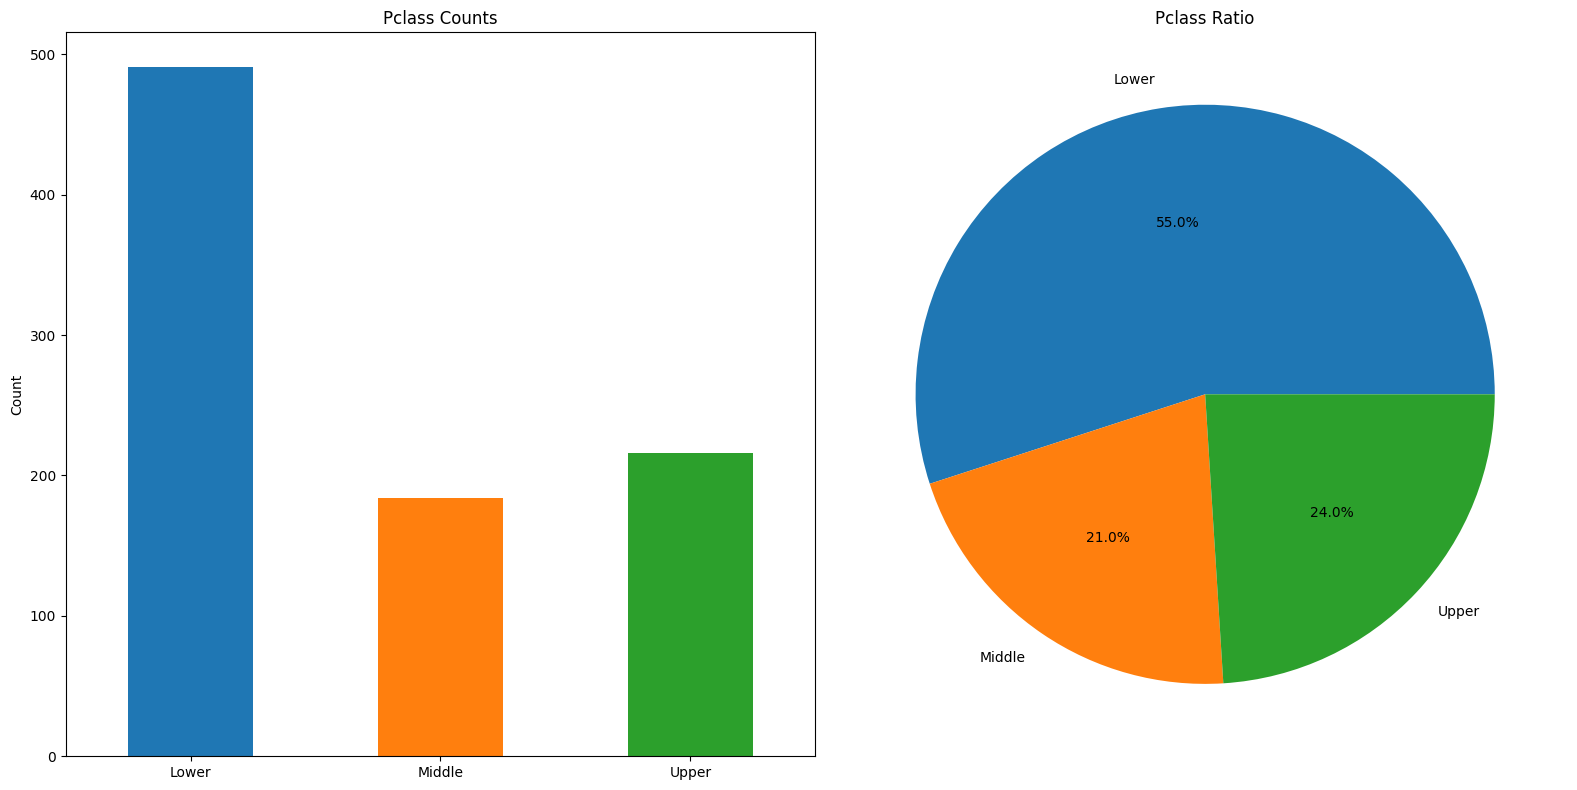

Total number of Sex: 891


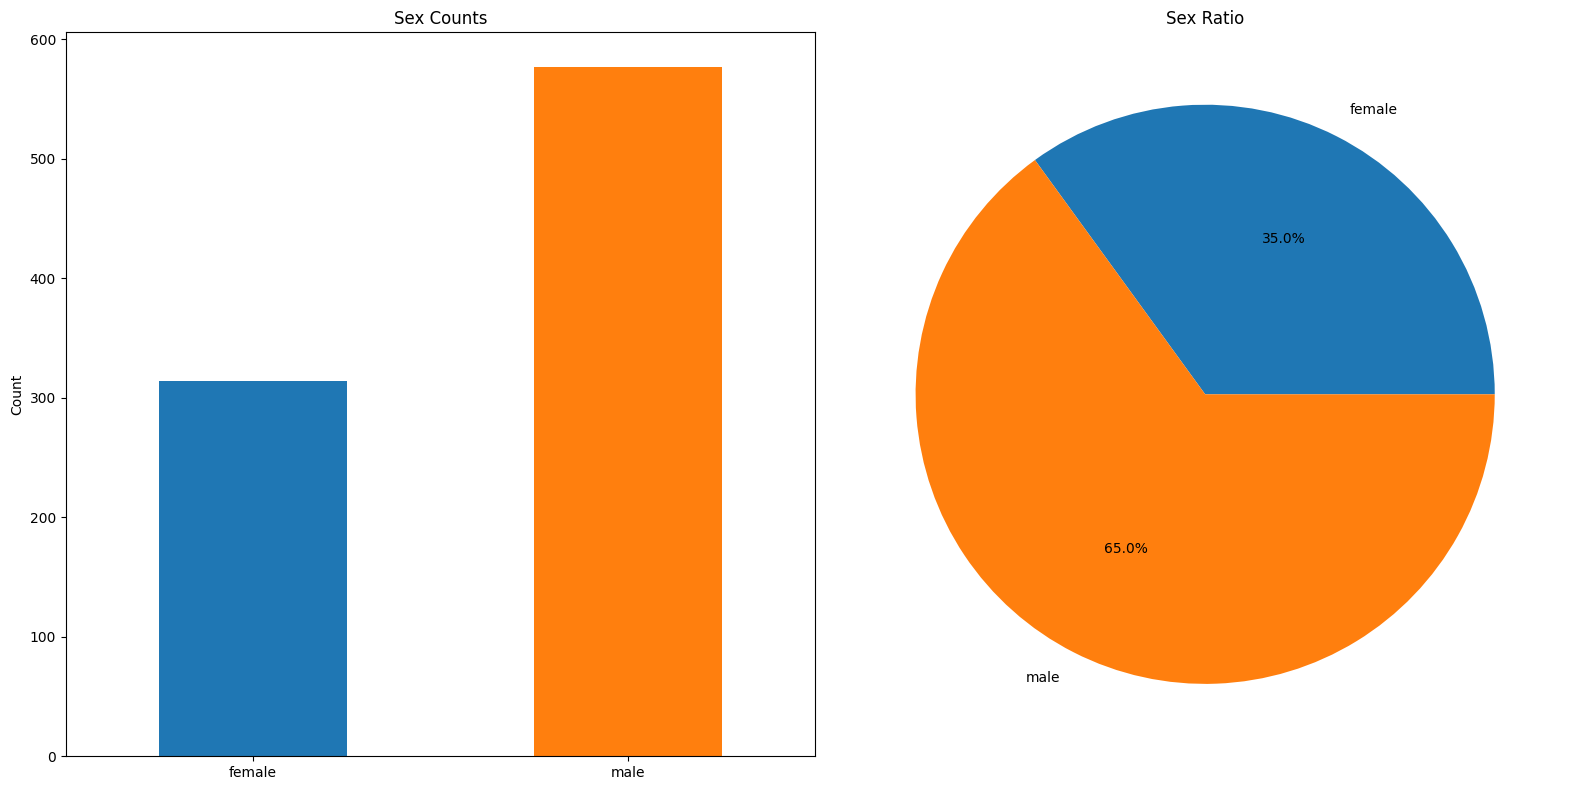

Total number of Age: 891


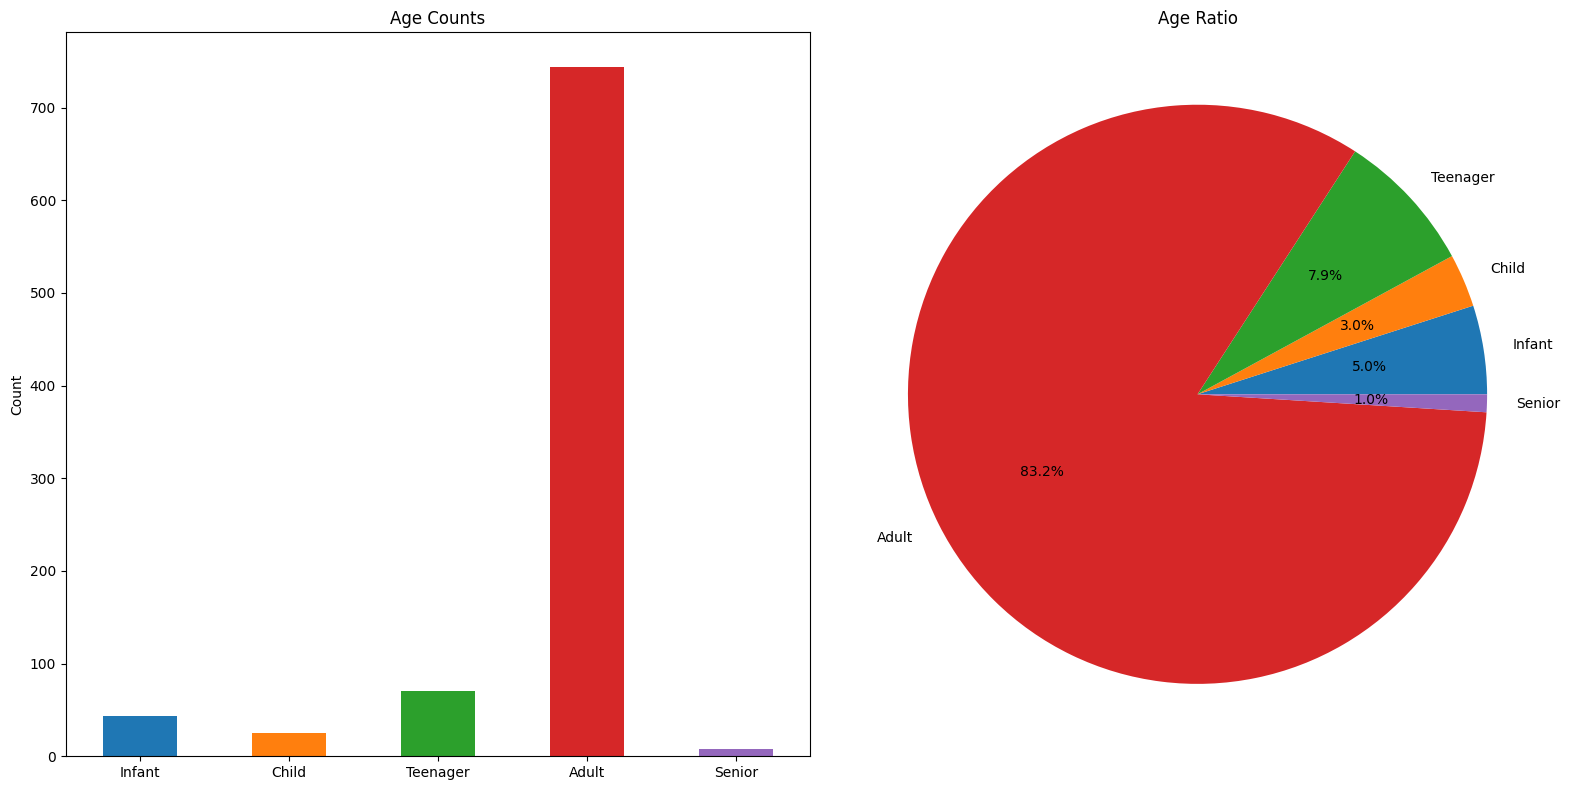

Total number of Embarked: 891


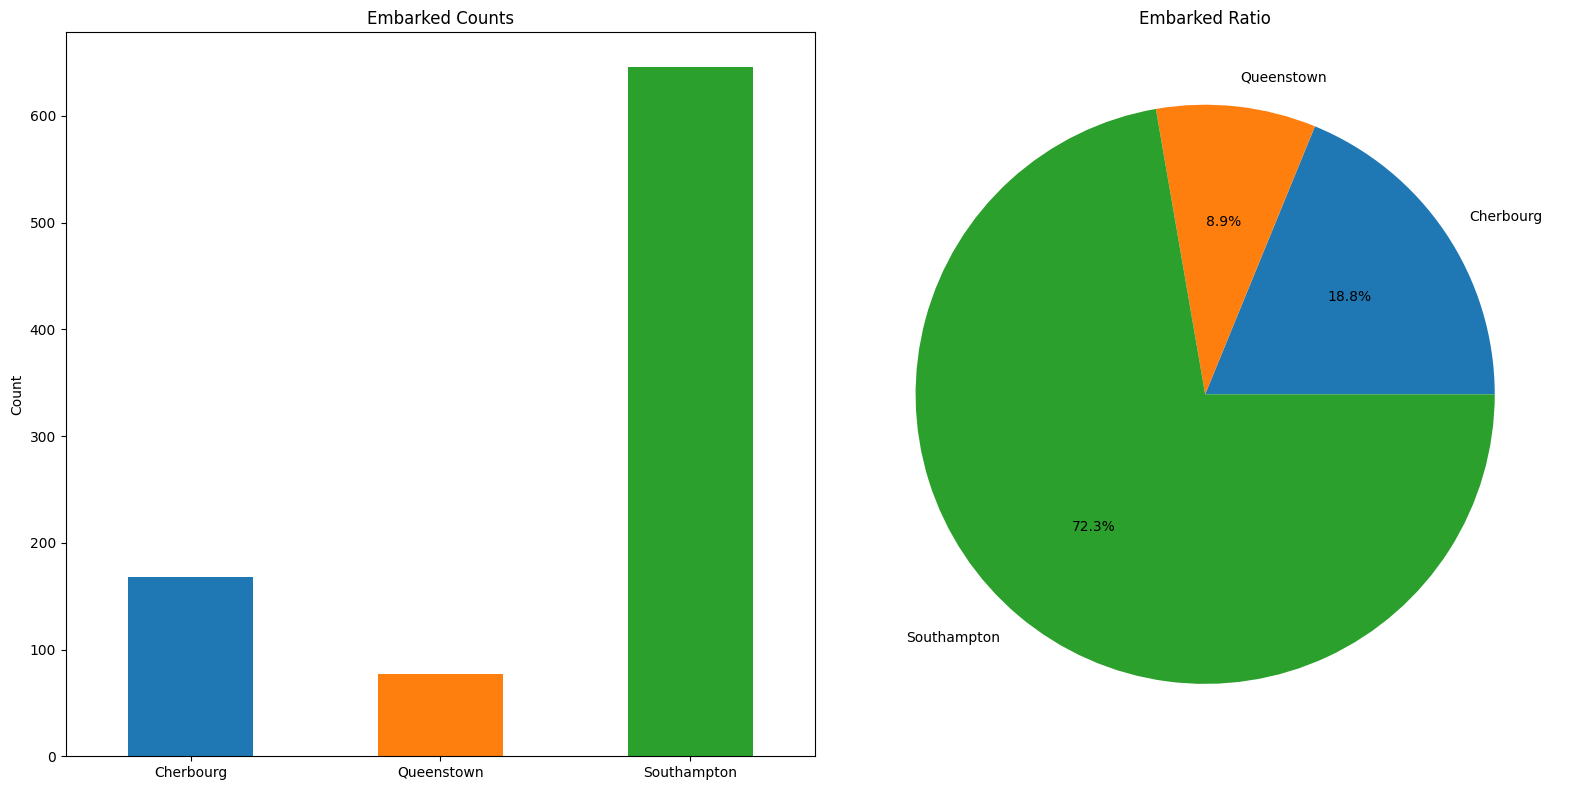

Total number of FamilySize: 891


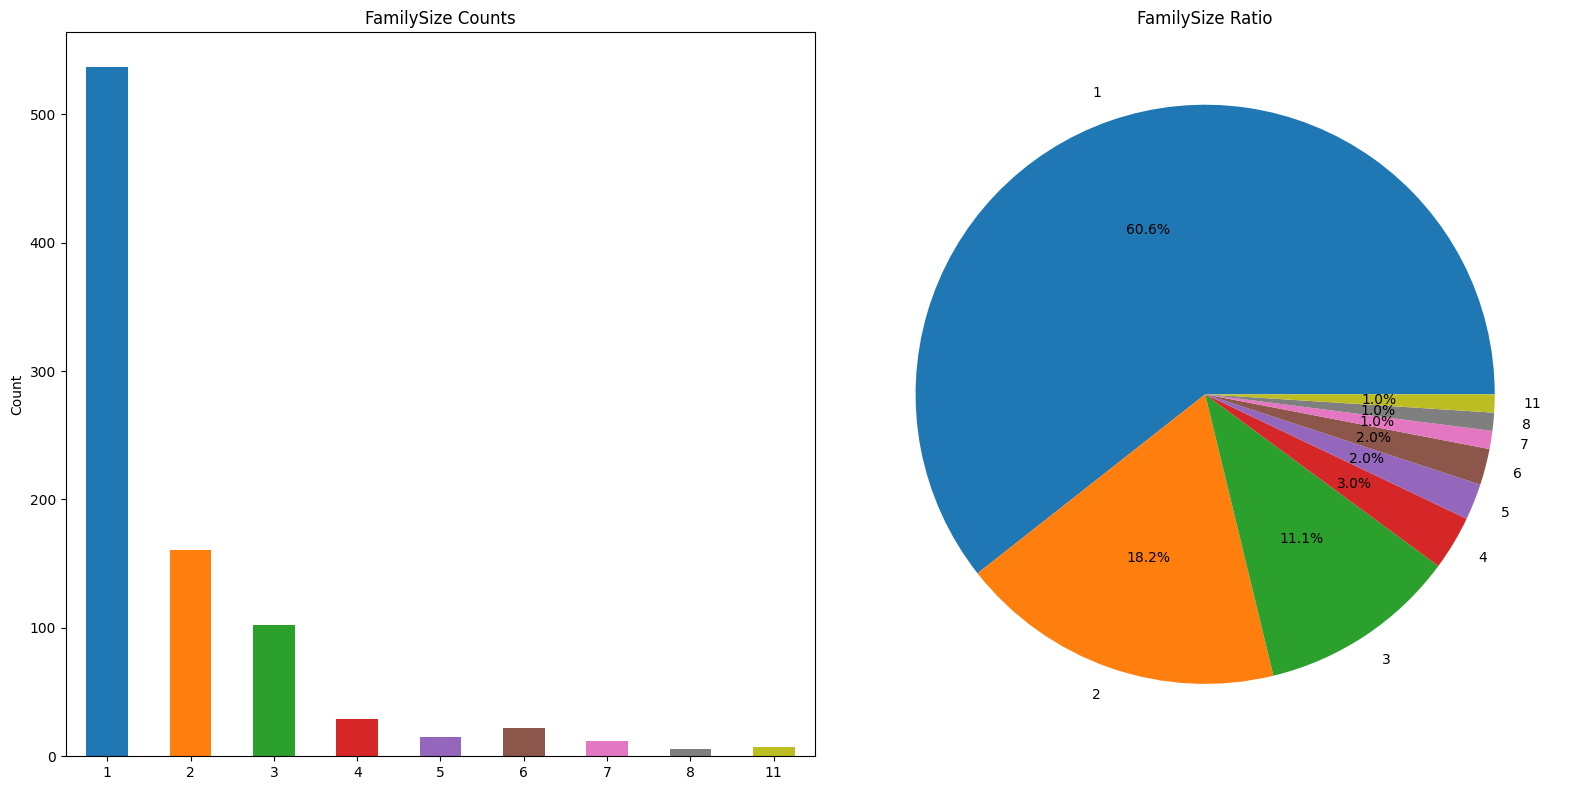

In [15]:
for col in categorical_df.columns:
    group_by_col_and_plot(categorical_df, col)

## Bivariate/Multivariate Analysis

In [16]:
from scipy.stats import chi2_contingency
def is_df_significant(gr, threshold=0.05):
    _, p, _, _ = chi2_contingency(gr)
    if p < threshold:
        print('The columns are statistically significant with p_value =', p)
    else:
        print('The columns are statistically insignificant with p_value =', p)
        
    

def group_by_2_cols(df, col_1, col_2):
    gr = df.groupby([col_1, col_2], observed=False).size().unstack(col_1, fill_value=0)
    print(gr)
    
    return gr

def plot_2_cols_chart(gr, col_1, col_2):
    gr_total = gr.sum(axis=1)
    gr = np.round(gr.divide(gr_total, axis=0) * 100, 2)
    gr_total_percentage = np.round((gr_total/gr_total.sum())*100, 2)
    
    colors = sns.color_palette(n_colors=df[col_2].nunique())
    
    # Create subplots
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar chart
    gr.plot(kind='bar', ax=ax1, color=colors, title=f'Proportion of {col_1} per {col_2}')
    
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%.2f')
    
    ax1.set_xlabel('')
    ax1.set_ylabel('%', rotation=1)
    ax1.tick_params(axis='x', rotation=0)
    
    # Pie chart
    gr_total_percentage.plot(kind='pie', ax=ax2, colors=colors, title=f'{col} Ratio', autopct='%1.1f%%', ylabel='')  

    plt.tight_layout()
    plt.show()
    
    return

Survived   No  Yes
Age               
Infant     13   31
Child      16    9
Teenager   40   30
Adult     473  271
Senior      7    1


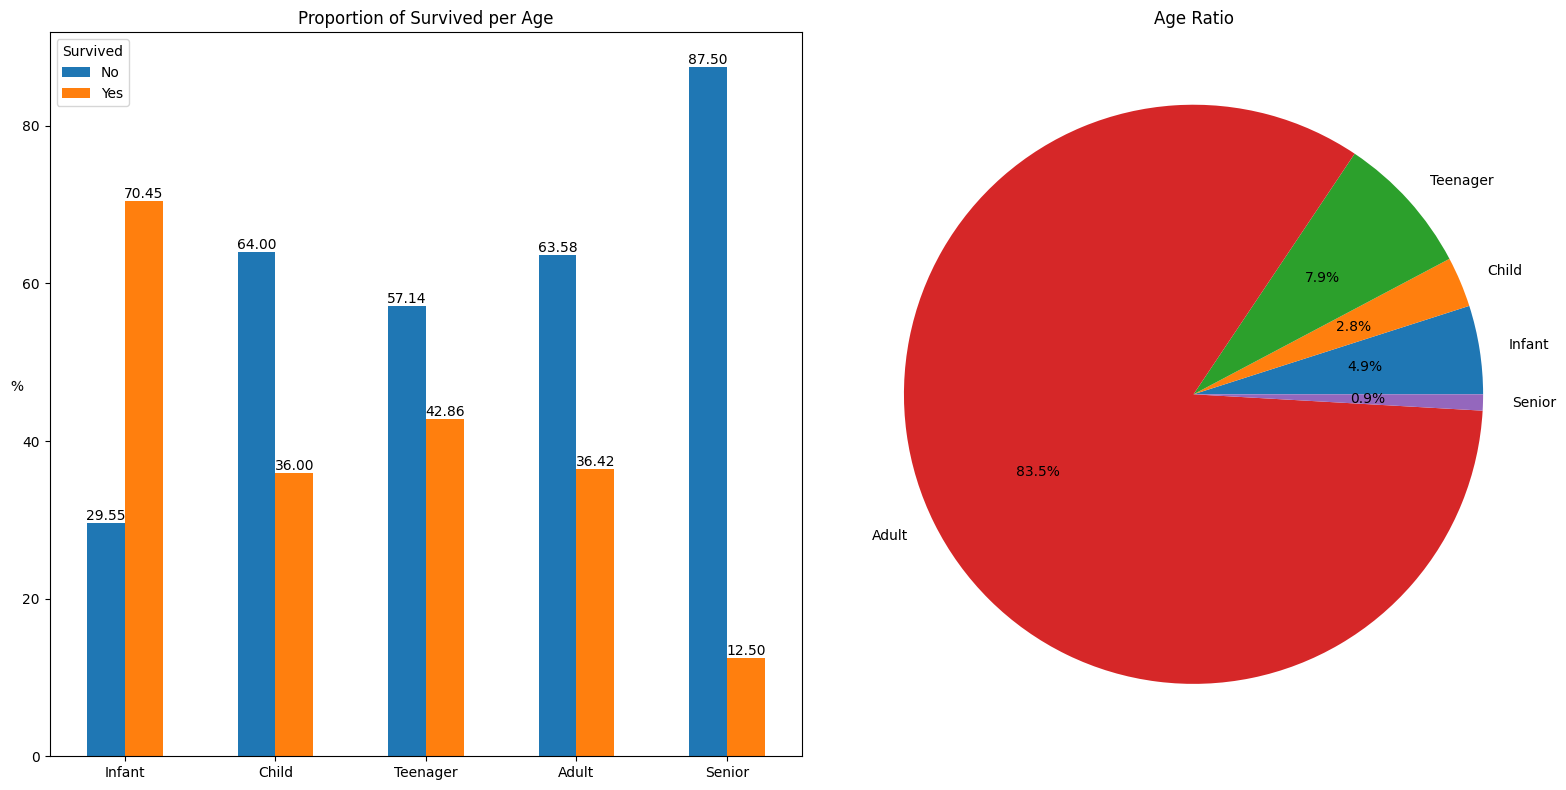

The columns are statistically significant with p_value = 0.00011230130477783057
Survived      No  Yes
Embarked             
Cherbourg     75   93
Queenstown    47   30
Southampton  427  219


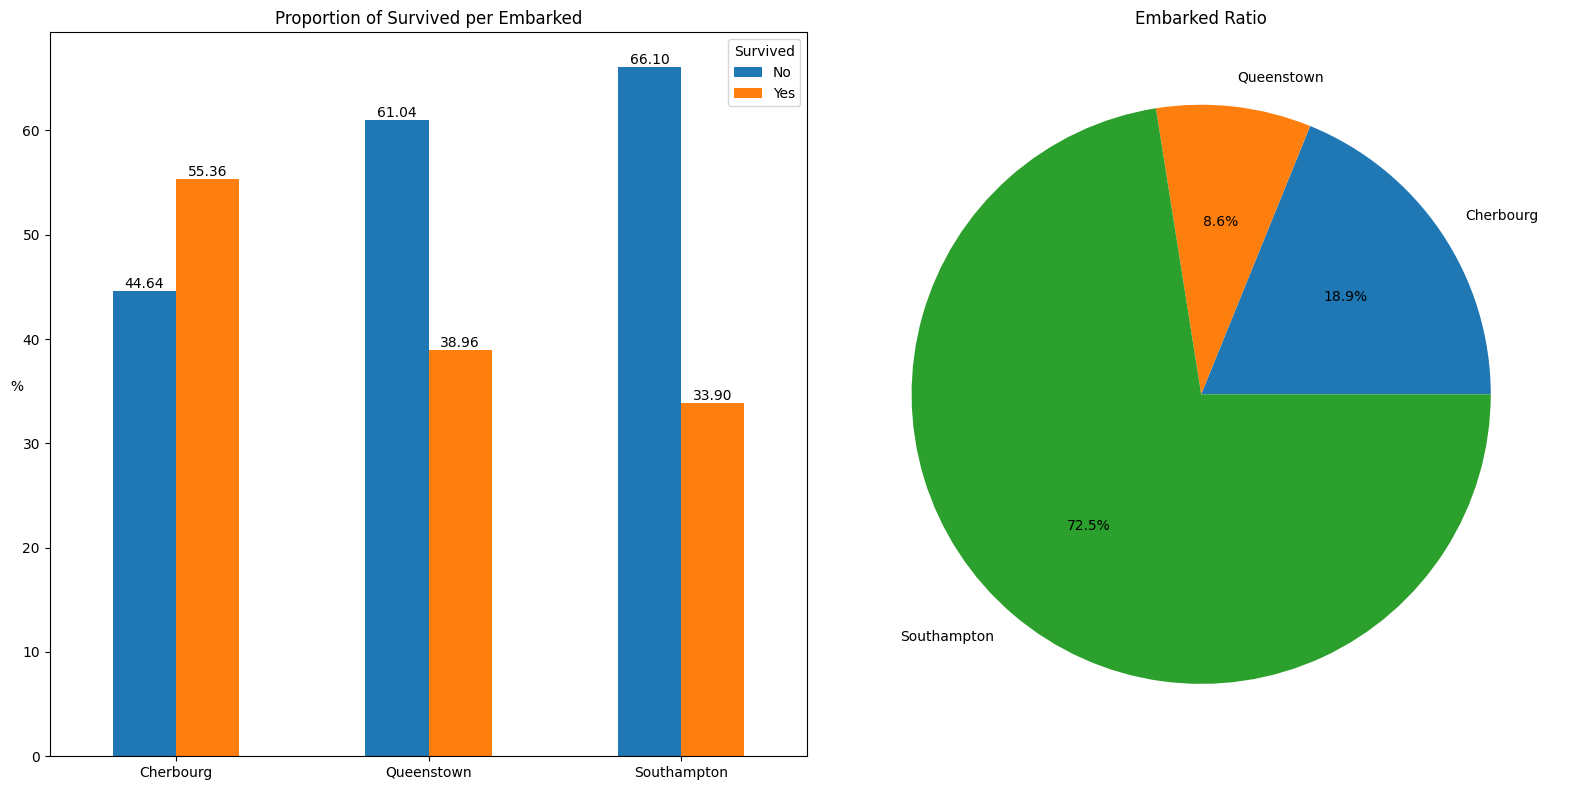

The columns are statistically significant with p_value = 2.3008626481449577e-06
Survived     No  Yes
FamilySize          
1           374  163
2            72   89
3            43   59
4             8   21
5            12    3
6            19    3
7             8    4
8             6    0
11            7    0


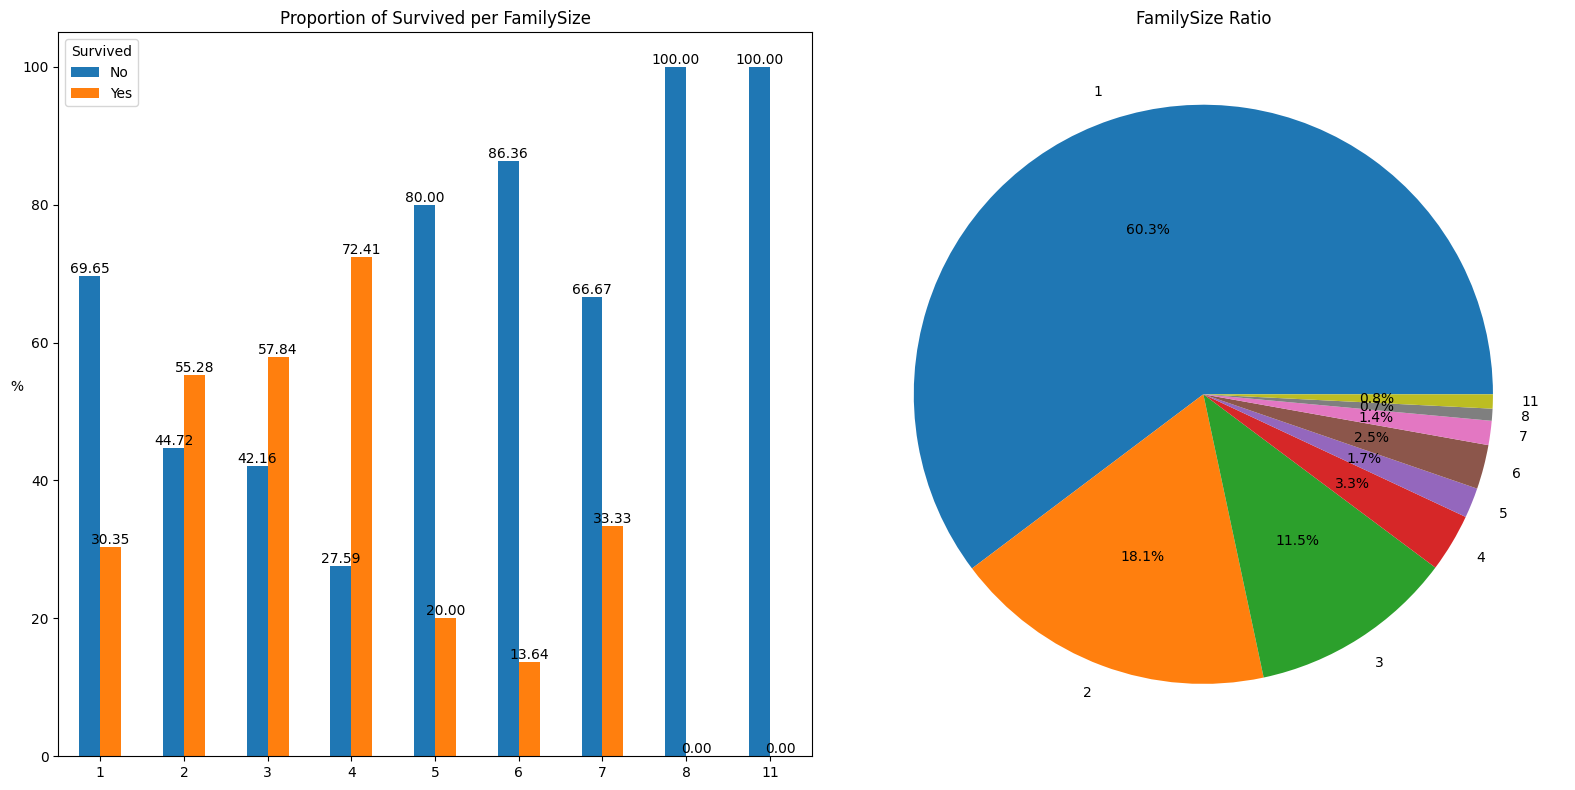

The columns are statistically significant with p_value = 3.579668975443533e-14
Survived   No  Yes
Pclass            
Lower     372  119
Middle     97   87
Upper      80  136


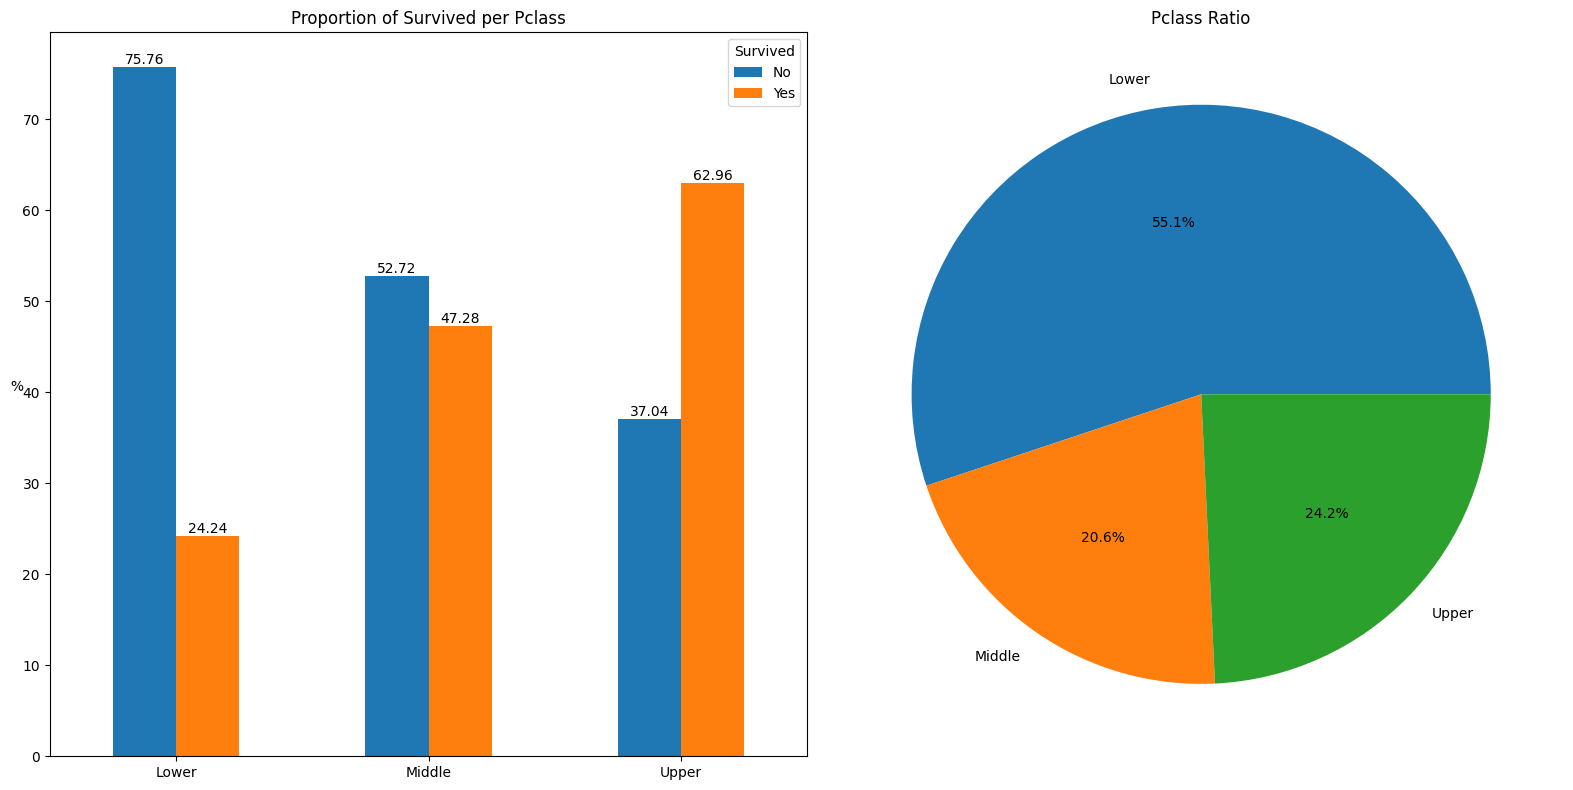

The columns are statistically significant with p_value = 4.5492517112987287e-23
Survived   No  Yes
Sex               
female     81  233
male      468  109


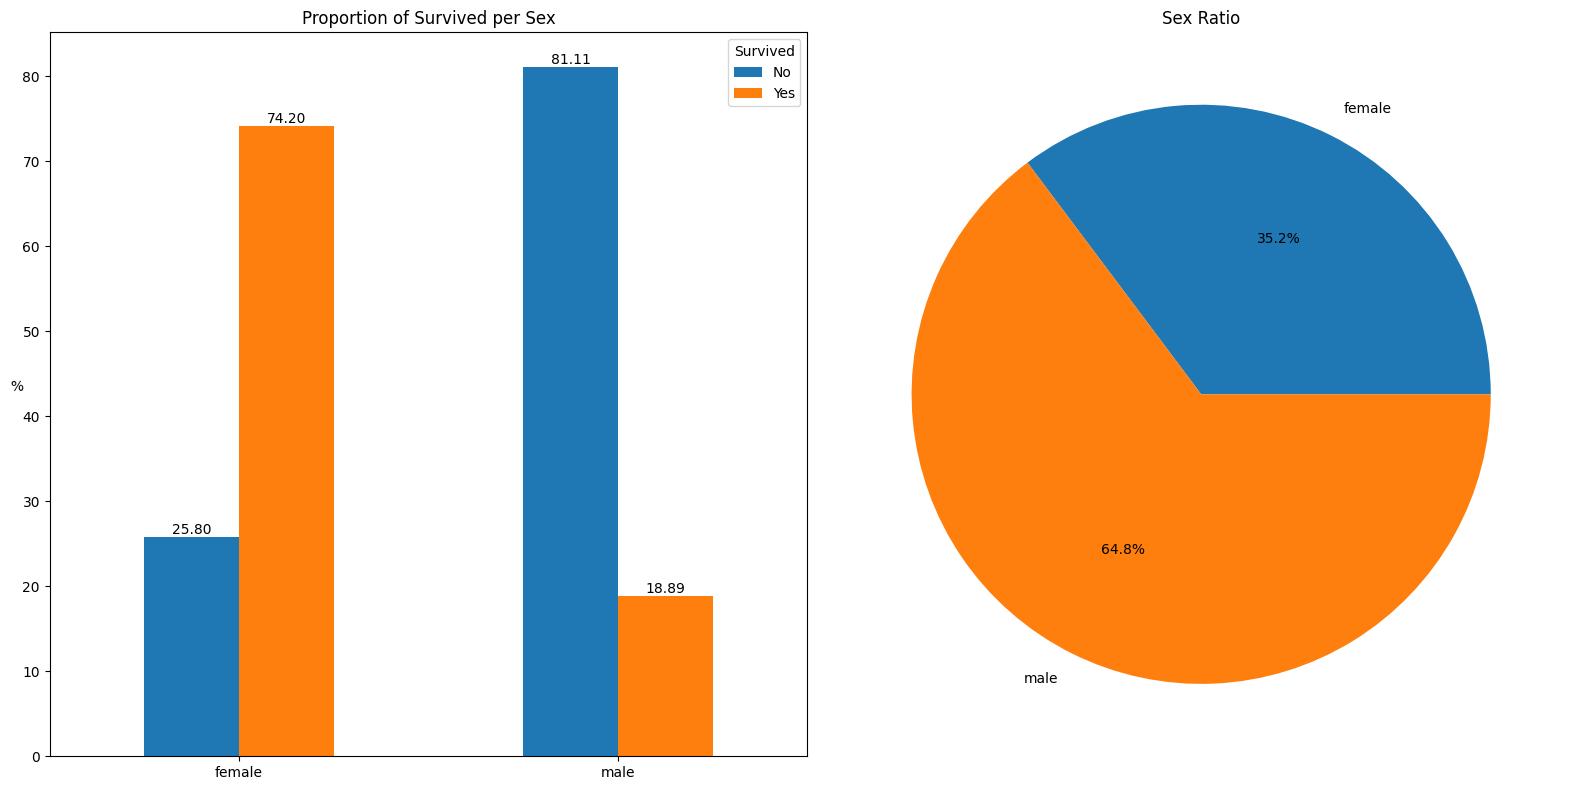

The columns are statistically significant with p_value = 1.1973570627755645e-58


In [17]:
for col in categorical_df.columns.difference(['Survived']):
    gr = group_by_2_cols(categorical_df, col_1='Survived', col_2=col)
    plot_2_cols_chart(gr, col_1='Survived', col_2=col)
    is_df_significant(gr, threshold=0.001)
        

By bivariate analysis of the statistically significant columns with the survivors:

- By age, infants are more likely to survive, while the opposite are more likely to seniors
- By family size, people with family size from 2-4 is more likely to survive
- By PClass, upper class is more likely to survive, while lower class is the opposite
- By sex, female is more likely to survive than male

Can group infants with female is a strong indicator of survival rate, and family size 2-4 with PClass upper as a moderately strong indicator.

## Feature Engineering

In [18]:
df.head()

,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,FamilySize,Title,LastName
0,No,Lower,"Braund, Mr. Owen Harris",male,Adult,A/5 21171,7.2500,Southampton,2,Mr,Braund
1,Yes,Upper,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,Adult,PC 17599,71.2833,Cherbourg,2,Mrs,Cumings
2,Yes,Lower,"Heikkinen, Miss. Laina",female,Adult,STON/O2. 3101282,7.9250,Southampton,1,Miss,Heikkinen
3,Yes,Upper,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,Adult,113803,53.1000,Southampton,2,Mrs,Futrelle
4,No,Lower,"Allen, Mr. William Henry",male,Adult,373450,8.0500,Southampton,1,Mr,Allen


Survived              No  Yes
is_infant_or_female          
False                460  103
True                  89  239


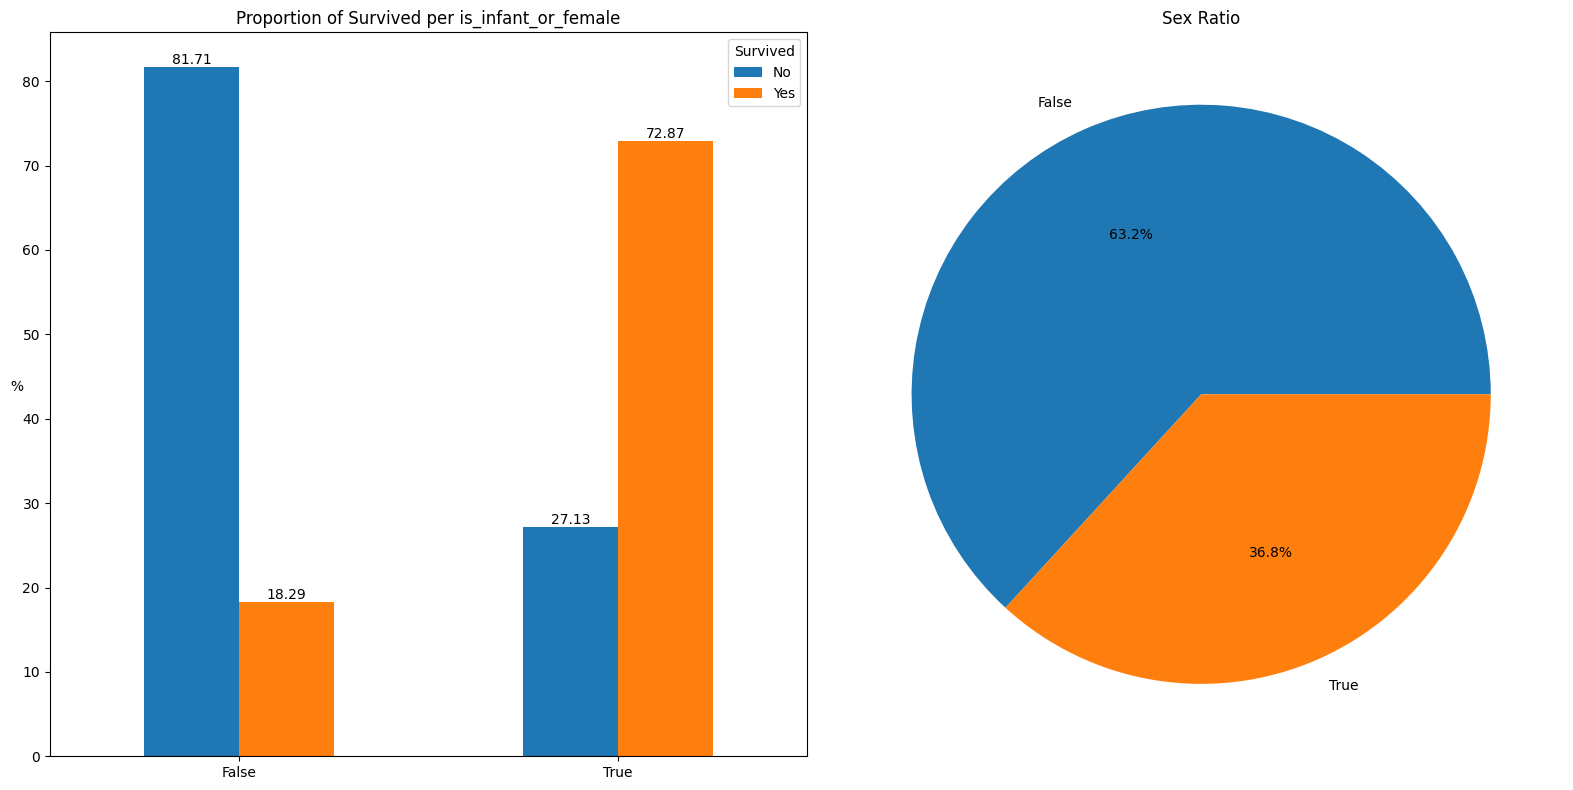

The columns are statistically significant with p_value = 3.354319128434374e-58


In [19]:
df['is_infant_or_female'] = ((df['Age'] == 'Child') | (df['Sex'] == 'female')).astype('category')

gr = group_by_2_cols(df, col_1='Survived', col_2='is_infant_or_female')
plot_2_cols_chart(gr, col_1='Survived', col_2='is_infant_or_female')
is_df_significant(gr, threshold=0.0001)

In [20]:
df['FamilyID'] = df['LastName'] + df['FamilySize'].astype(str)
df['ClassPortID'] = df['Pclass'] + df['Embarked']
df.head()

,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,FamilySize,Title,LastName,is_infant_or_female,FamilyID,ClassPortID
0,No,Lower,"Braund, Mr. Owen Harris",male,Adult,A/5 21171,7.2500,Southampton,2,Mr,Braund,False,Braund2,LowerSouthampton
1,Yes,Upper,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,Adult,PC 17599,71.2833,Cherbourg,2,Mrs,Cumings,True,Cumings2,UpperCherbourg
2,Yes,Lower,"Heikkinen, Miss. Laina",female,Adult,STON/O2. 3101282,7.9250,Southampton,1,Miss,Heikkinen,True,Heikkinen1,LowerSouthampton
3,Yes,Upper,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,Adult,113803,53.1000,Southampton,2,Mrs,Futrelle,True,Futrelle2,UpperSouthampton
4,No,Lower,"Allen, Mr. William Henry",male,Adult,373450,8.0500,Southampton,1,Mr,Allen,False,Allen1,LowerSouthampton


In [21]:
print(df['Title'].unique())
df.loc[df['FamilyID'] == 'Braund2']

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'the Countess' 'Jonkheer']


,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,FamilySize,Title,LastName,is_infant_or_female,FamilyID,ClassPortID
0,No,Lower,"Braund, Mr. Owen Harris",male,Adult,A/5 21171,7.2500,Southampton,2,Mr,Braund,False,Braund2,LowerSouthampton
477,No,Lower,"Braund, Mr. Lewis Richard",male,Adult,3460,7.0458,Southampton,2,Mr,Braund,False,Braund2,LowerSouthampton


In [22]:
df['FamilySize'] = pd.cut(df['FamilySize'], bins=[0, 1, 4, 15], labels=['Solo', 'Average', 'Large'])

Survived     No  Yes
FamilySize          
Solo        374  163
Average     123  169
Large        52   10


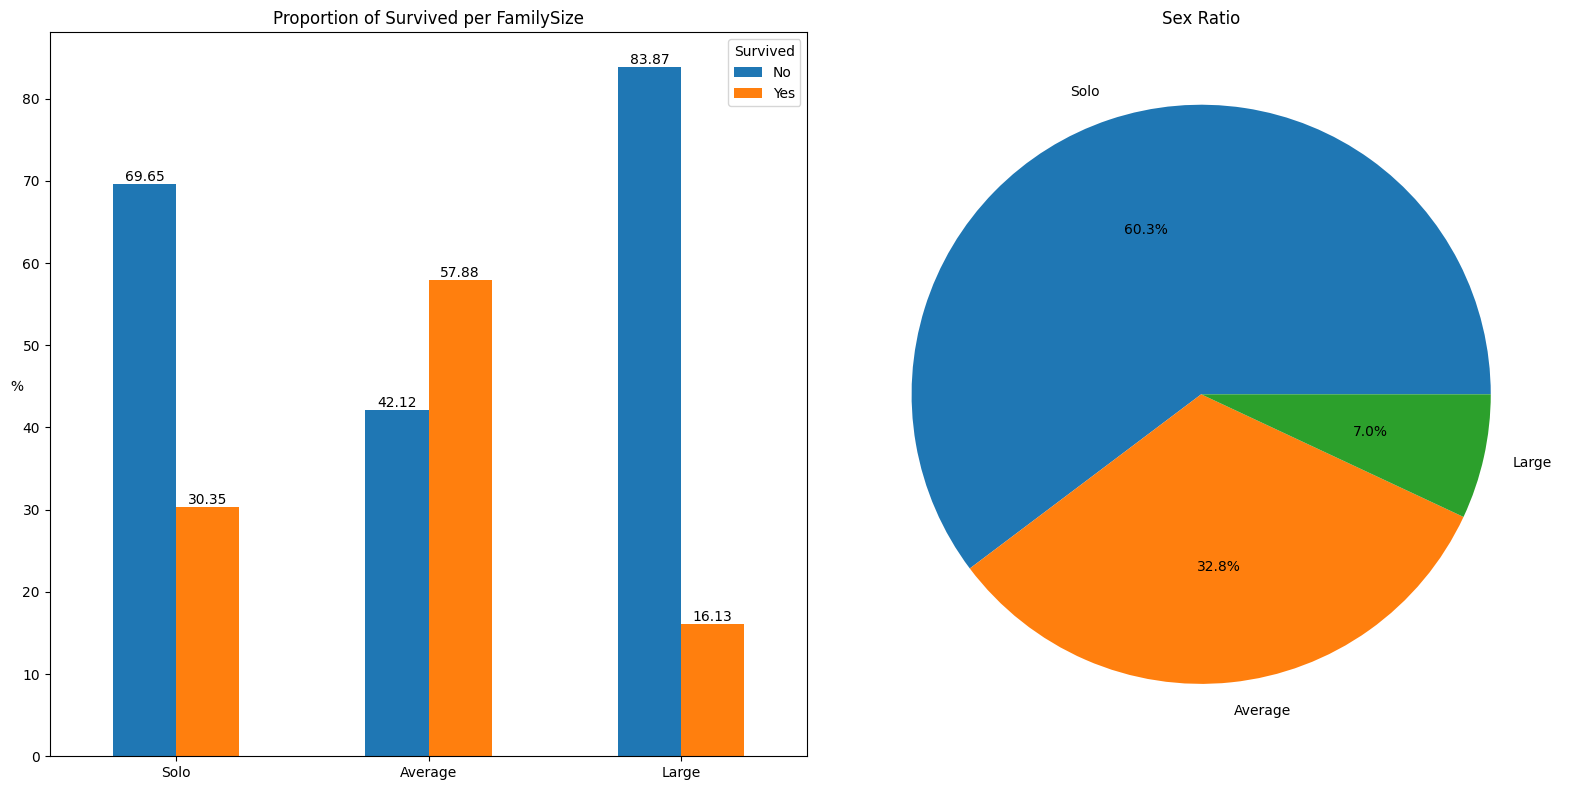

The columns are statistically significant with p_value = 6.522919536640473e-17


In [23]:
gr = group_by_2_cols(df, col_1='Survived', col_2='FamilySize')
plot_2_cols_chart(gr, col_1='Survived', col_2='FamilySize')
is_df_significant(gr, threshold=0.0001)

Pclass       Lower  Middle  Upper
Embarked                         
Cherbourg       66      17     85
Queenstown      72       3      2
Southampton    353     164    129


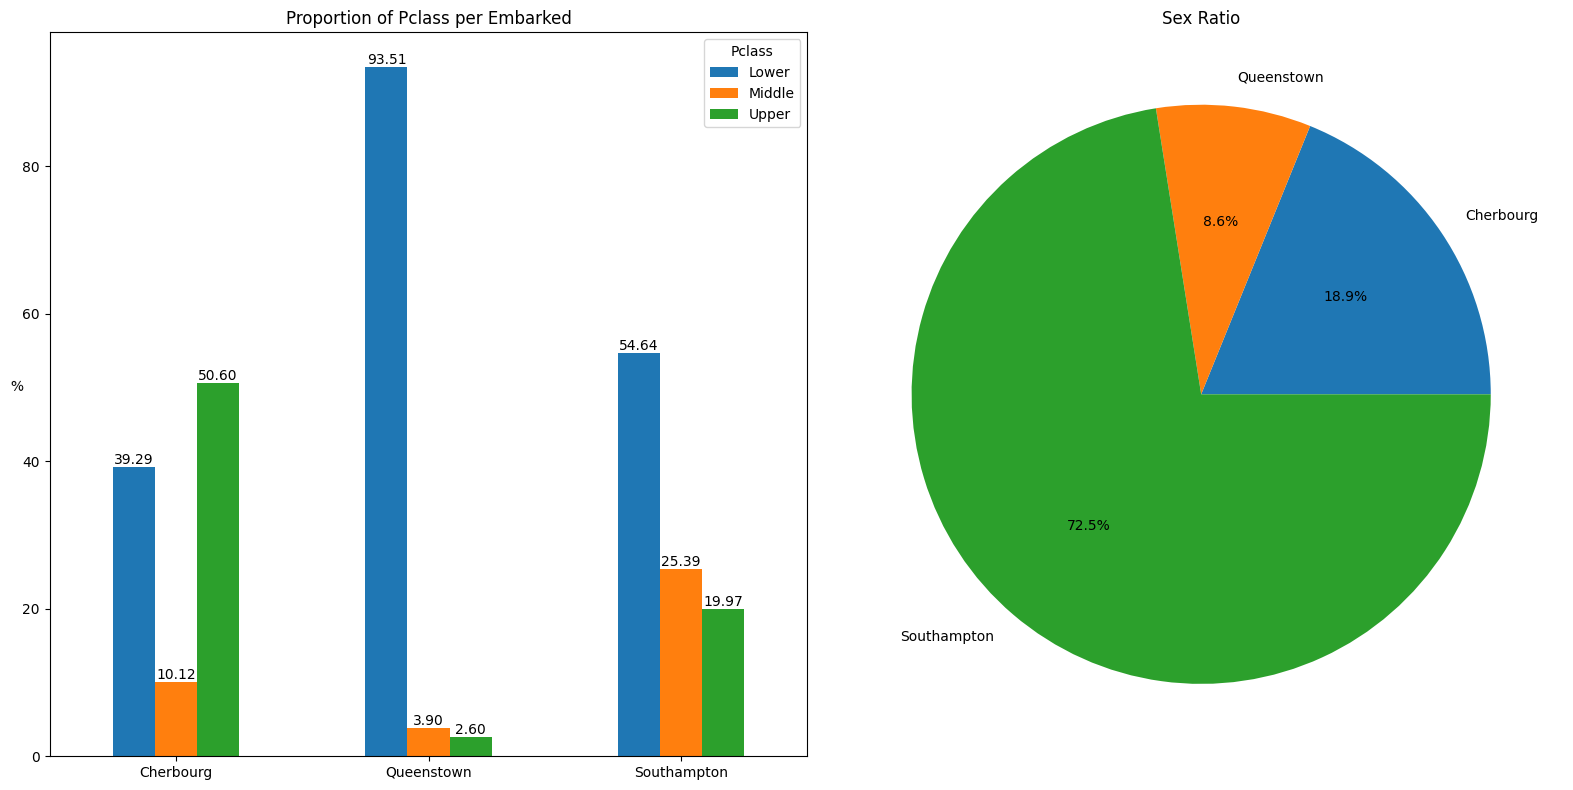

The columns are statistically significant with p_value = 1.4569383279917686e-25
Survived      No  Yes
Embarked             
Cherbourg     75   93
Queenstown    47   30
Southampton  427  219


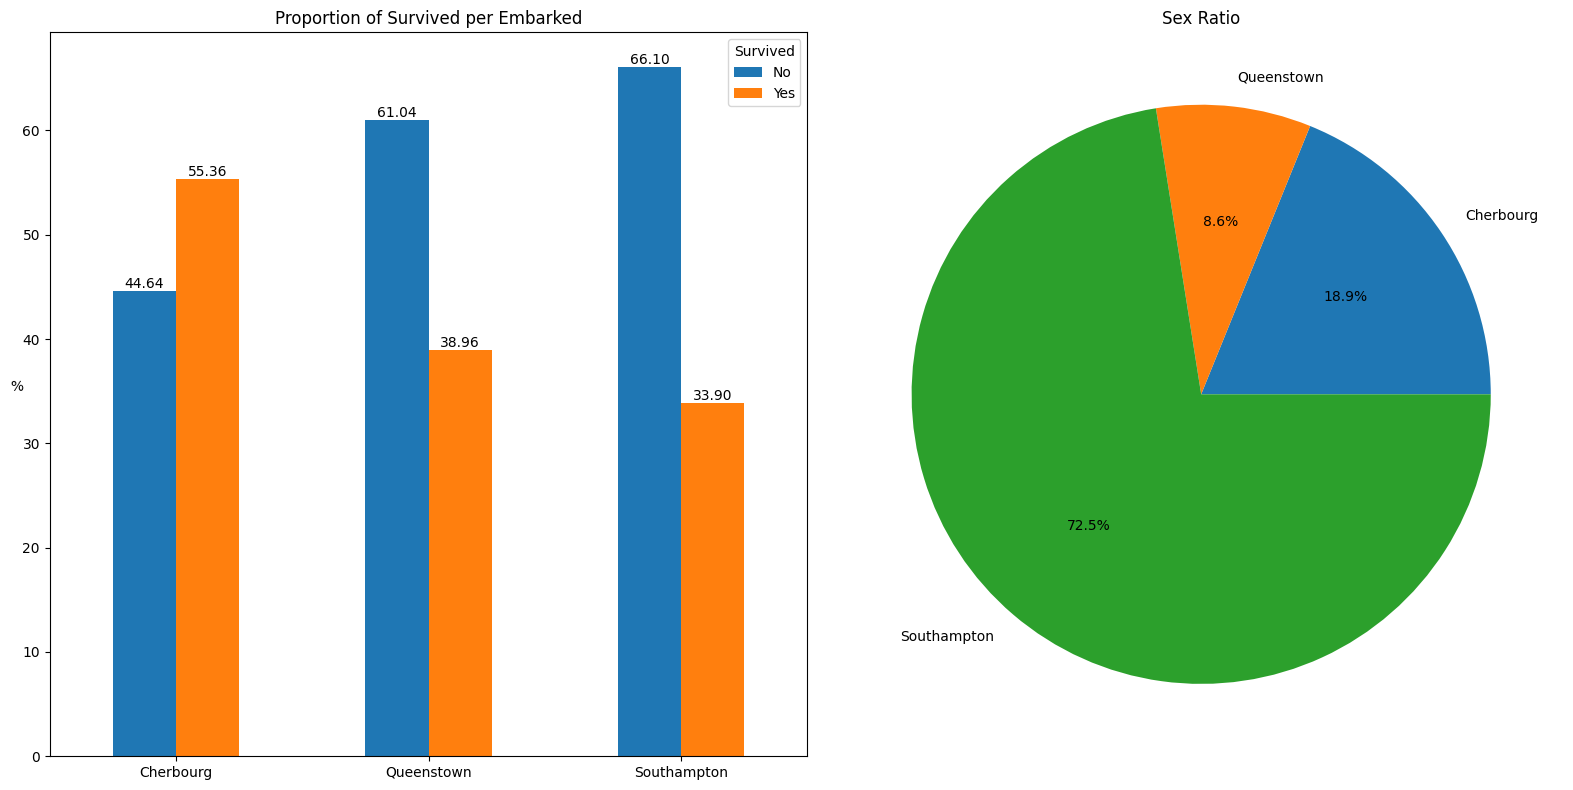

The columns are statistically significant with p_value = 2.3008626481449577e-06
Survived   No  Yes
Pclass            
Lower     372  119
Middle     97   87
Upper      80  136


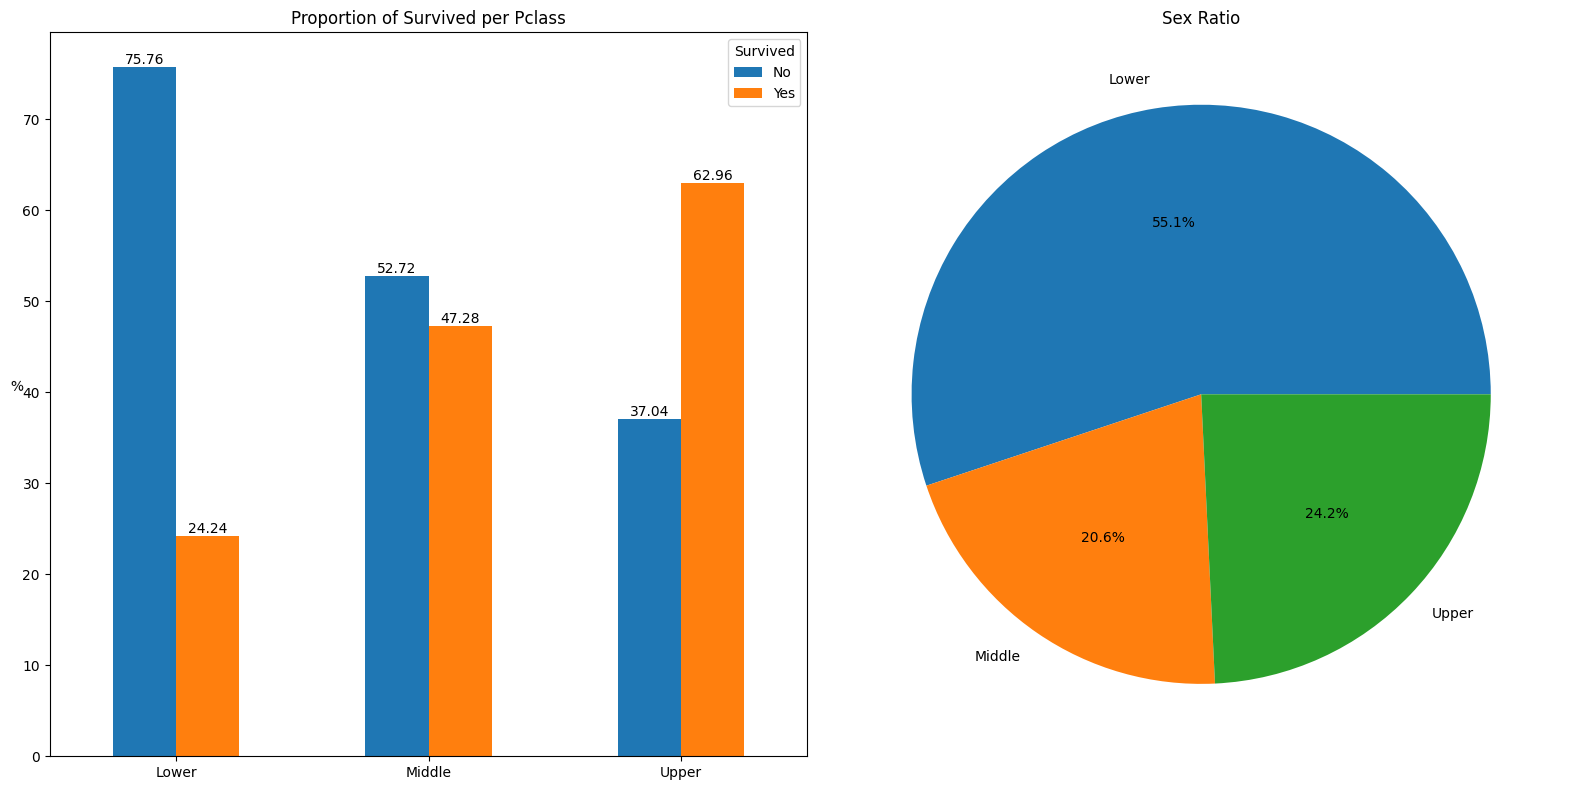

The columns are statistically significant with p_value = 4.5492517112987287e-23


In [24]:
gr = group_by_2_cols(df, col_1='Pclass', col_2='Embarked')
plot_2_cols_chart(gr, col_1='Pclass', col_2='Embarked')
is_df_significant(gr, threshold=0.0001)

gr = group_by_2_cols(df, col_1='Survived', col_2='Embarked')
plot_2_cols_chart(gr, col_1='Survived', col_2='Embarked')
is_df_significant(gr, threshold=0.0001)

gr = group_by_2_cols(df, col_1='Survived', col_2='Pclass')
plot_2_cols_chart(gr, col_1='Survived', col_2='Pclass')
is_df_significant(gr, threshold=0.0001)

In [25]:
# Filter rows where 'class' is 'upper', then sort by 'fare' in descending order
sorted_df = df[(df['Pclass'] == 'Lower') & (df['Survived'] == 'Yes')].sort_values(by='Fare', ascending=True)  
print(sorted_df)

    Survived Pclass                               Name     Sex    Age  \
271      Yes  Lower       Tornquist, Mr. William Henry    male  Adult   
804      Yes  Lower            Hedman, Mr. Oskar Arvid    male  Adult   
127      Yes  Lower          Madsen, Mr. Fridtjof Arne    male  Adult   
19       Yes  Lower            Masselmani, Mrs. Fatima  female  Adult   
553      Yes  Lower  Leeni, Mr. Fahim ("Philip Zenni")    male  Adult   
..       ...    ...                                ...     ...    ...   
74       Yes  Lower                      Bing, Mr. Lee    male  Adult   
509      Yes  Lower                     Lang, Mr. Fang    male  Adult   
643      Yes  Lower                    Foo, Mr. Choong    male  Adult   
692      Yes  Lower                       Lam, Mr. Ali    male  Adult   
838      Yes  Lower                    Chip, Mr. Chang    male  Adult   

      Ticket     Fare     Embarked FamilySize Title    LastName  \
271     LINE   0.0000  Southampton       Solo    Mr   To

Pclass    Lower  Middle  Upper
Fare                          
0.0000        4       6      5
4.0125        1       0      0
5.0000        0       0      1
6.2375        1       0      0
6.4375        1       0      0
...         ...     ...    ...
227.5250      0       0      4
247.5208      0       0      2
262.3750      0       0      2
263.0000      0       0      4
512.3292      0       0      3

[248 rows x 3 columns]


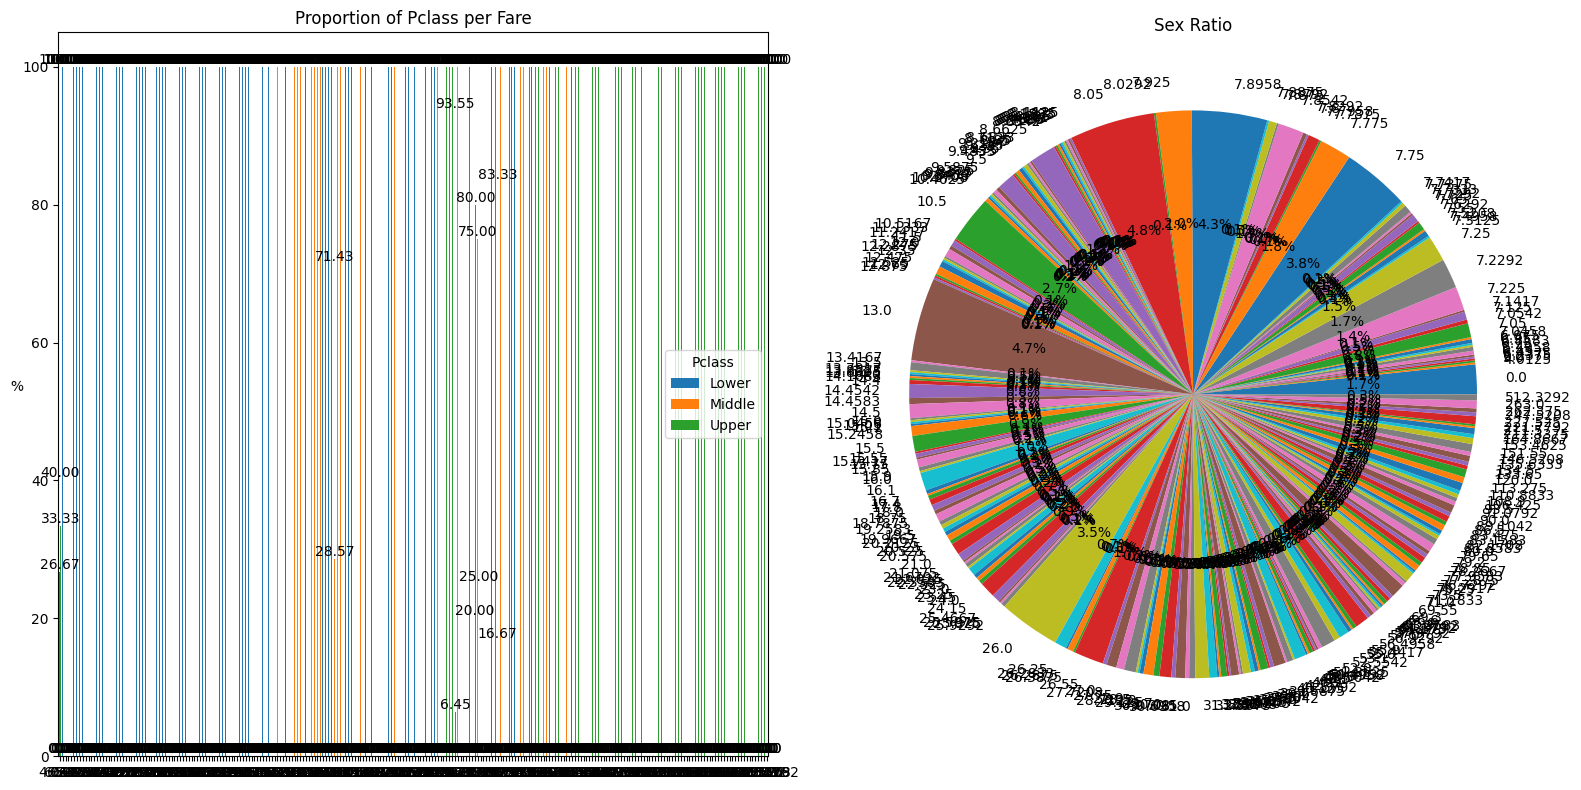

The columns are statistically significant with p_value = 1.0986166679130083e-131


In [26]:
gr = group_by_2_cols(df, col_1='Pclass', col_2='Fare')
plot_2_cols_chart(gr, col_1='Pclass', col_2='Fare')
is_df_significant(gr, threshold=0.0001)

In [27]:
df['is_upper_class'] = df['Pclass'] == 'Upper'
df['is_from_cherbourg'] = df['Embarked'] == 'Cherbourg'
df['is_family_size_average'] = df['FamilySize'] == 'Average'
df['is_female'] = df['Sex'] == 'female'
df['is_children'] = df['Age'] != 'Adult'

df.head()

,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,FamilySize,Title,LastName,is_infant_or_female,FamilyID,ClassPortID,is_upper_class,is_from_cherbourg,is_family_size_average,is_female,is_children
0,No,Lower,"Braund, Mr. Owen Harris",male,Adult,A/5 21171,7.2500,Southampton,Average,Mr,Braund,False,Braund2,LowerSouthampton,False,False,True,False,False
1,Yes,Upper,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,Adult,PC 17599,71.2833,Cherbourg,Average,Mrs,Cumings,True,Cumings2,UpperCherbourg,True,True,True,True,False
2,Yes,Lower,"Heikkinen, Miss. Laina",female,Adult,STON/O2. 3101282,7.9250,Southampton,Solo,Miss,Heikkinen,True,Heikkinen1,LowerSouthampton,False,False,False,True,False
3,Yes,Upper,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,Adult,113803,53.1000,Southampton,Average,Mrs,Futrelle,True,Futrelle2,UpperSouthampton,True,False,True,True,False
4,No,Lower,"Allen, Mr. William Henry",male,Adult,373450,8.0500,Southampton,Solo,Mr,Allen,False,Allen1,LowerSouthampton,False,False,False,False,False


## Fill NaN more properly

In [205]:
df = pd.read_csv('../data/raw/train.csv')
df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [237]:
df.sort_values('Fare')

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize,FamilyID
815,0,0,0,NaN,0.0000,1.0,NaN,1,NaN
806,0,0,0,3.0,0.0000,1.0,NaN,1,NaN
413,0,1,0,NaN,0.0000,1.0,NaN,1,NaN
481,0,1,0,NaN,0.0000,1.0,NaN,1,NaN
302,0,2,0,2.0,0.0000,1.0,NaN,1,NaN
...,...,...,...,...,...,...,...,...,...
438,0,0,0,3.0,263.0000,1.0,NaN,6,NaN
341,1,0,1,2.0,263.0000,1.0,NaN,6,NaN
737,1,0,0,2.0,512.3292,0.0,NaN,1,NaN
679,1,0,0,3.0,512.3292,0.0,NaN,2,NaN


In [305]:
import mlflow
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, recall_score, f1_score

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare features for training:
    - drop Name, Ticket, Fare, and Cabin
    - fill missing cells of Age and Embarke
    - combine SibSp and Parch into 1 column FamilySize
    - split age to 5 groups: Infant, child, Teenager, Adult, and Senior (0-4)
    - encode categorical columns: Sex, Embarked, PClass
    - add 2 significant indicators: is_infant_or_female, is_family_size_2_to_4_or_upper_class
    """
    
    # Fill missing ages with the median of people with the same PClass and Sex
    # Count NaN values in 'Age' before filling
    # nan_count_before = df['Age'].isna().sum()

    # Perform the fill operation
    # df = df.fillna({'Age': df.groupby(['Pclass', 'Sex'])['Age'].transform('median')})

    # The number of filled values is equal to nan_count_before
    # print(f"Number of Age values filled: {nan_count_before}")
    # Fill missing Embarked with the most frequent port of people with the same PClass and Sex
    # df = df.fillna({'Embarked': df.groupby(['Pclass', 'Sex'])['Embarked'].transform(lambda x: x.mode()[0])})
    
    df[['Title', 'LastName']] = df['Name'].apply(lambda x: pd.Series(extract_title_and_last_name(x))).astype('category')
    
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df = df.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin'], axis=1)
    
    # df['Age'] = pd.cut(df['Age'], bins=[0, 6, 12, 35, 65, 150], labels=[0, 1, 2, 3, 4])
    # df['Fare'] = pd.cut(df['Fare'], bins=[0, 20, 75, 1000], labels=[0, 1, 2])
    
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'C': 0, 'S': 1, 'Q': 2})
    df['Pclass'] = df['Pclass'] - 1

    return df

df = pd.read_csv('../data/raw/train.csv')
df = build_features(df)

In [306]:
print(df.dtypes)

target_col = 'Survived'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
 
model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.11,
        max_depth=4,
        random_state=42,
        n_jobs=-1,
        enable_categorical=True,
        early_stopping_rounds=10,
        eval_metric="logloss"
)
    
with mlflow.start_run():
    # Define K-Fold
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Lists to store metrics for each fold
    accuracies = []
    recalls = []
    f1s = []
    
    # Loop through each fold
    for fold, (train_index, test_index) in enumerate(kf.split(X)):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
        
        eval_set = [(X_train_fold, y_train_fold), (X_test_fold, y_test_fold)]
        
        # Train model
        model.fit(X_train_fold, y_train_fold, eval_set=eval_set)
        preds = model.predict(X_test_fold)
        
        # Calculate metrics
        acc = accuracy_score(y_test_fold, preds)
        rec = recall_score(y_test_fold, preds)
        f1 = f1_score(y_test_fold, preds)
        
        # Store metrics
        accuracies.append(acc)
        recalls.append(rec)
        f1s.append(f1)
        
        # Log metrics for this fold
        mlflow.log_metric(f"accuracy_fold", acc, step=fold)
        mlflow.log_metric(f"recall_fold", rec, step=fold)
    
    # Log average and standard deviation
    mlflow.log_metric("accuracy_mean", np.mean(accuracies))
    mlflow.log_metric("accuracy_std", np.std(accuracies))
    mlflow.log_metric("recall_mean", np.mean(recalls))
    mlflow.log_metric("recall_std", np.std(recalls))
    
    # Log parameters and dataset
    mlflow.log_param("n_estimators", 300)
    train_ds = mlflow.data.from_pandas(df, source="training_data")
    mlflow.log_input(train_ds, context="training")
    
    print(f"K-Fold Complete. Avg F1 Score: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}. Avg Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}, Avg Recall: {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")

Survived         int64
Pclass           int64
Sex              int64
Age            float64
Fare           float64
Embarked       float64
Title         category
LastName      category
FamilySize       int64
dtype: object


[0]	validation_0-logloss:0.61082	validation_1-logloss:0.62944
[1]	validation_0-logloss:0.57009	validation_1-logloss:0.59074
[2]	validation_0-logloss:0.53638	validation_1-logloss:0.55723
[3]	validation_0-logloss:0.50810	validation_1-logloss:0.52811
[4]	validation_0-logloss:0.48475	validation_1-logloss:0.50591
[5]	validation_0-logloss:0.46423	validation_1-logloss:0.48858
[6]	validation_0-logloss:0.44739	validation_1-logloss:0.47280
[7]	validation_0-logloss:0.43262	validation_1-logloss:0.45976
[8]	validation_0-logloss:0.41911	validation_1-logloss:0.44983
[9]	validation_0-logloss:0.40772	validation_1-logloss:0.44155
[10]	validation_0-logloss:0.39771	validation_1-logloss:0.43268
[11]	validation_0-logloss:0.38921	validation_1-logloss:0.42639
[12]	validation_0-logloss:0.38115	validation_1-logloss:0.42076
[13]	validation_0-logloss:0.37413	validation_1-logloss:0.41693
[14]	validation_0-logloss:0.36827	validation_1-logloss:0.41321
[15]	validation_0-logloss:0.36254	validation_1-logloss:0.41094
[1

/home/hvtruong/Projects/Kaggle/.venv/lib/python3.11/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/home/hvtruong/Projects/Kaggle/.venv/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Miss

In [307]:
test_df = pd.read_csv('../data/raw/test.csv')
passengerId = test_df['PassengerId']
test_df = build_features(test_df)
preds = model.predict(test_df)
submission = pd.DataFrame({
    'PassengerId': passengerId,
    'Survived': preds
})
submission.head()
submission.to_csv('../data/raw/gender_submission.csv', index=False)

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plot feature importance based on 'weight' (default), 'gain', or 'cover'
plot_importance(model, importance_type='gain', max_num_features=15)
plt.show()

In [213]:
indices = np.where(y_test != preds)[0]
indices

array([  0,  16,  22,  27,  29,  31,  32,  33,  34,  36,  49,  65,  70,
        76,  78,  79,  84,  96,  97, 108, 109, 113, 131, 135, 141, 153,
       159, 161, 172, 173, 176])

In [214]:
false_preds = df.iloc[indices].sort_values('Survived')
false_preds

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize,FamilyID
0,0,2,0,2.0,7.2500,1.0,NaN,2,NaN
16,0,2,0,0.0,29.1250,2.0,NaN,6,NaN
27,0,0,0,2.0,263.0000,1.0,NaN,6,NaN
29,0,2,0,NaN,7.8958,1.0,NaN,1,NaN
33,0,1,0,5.0,10.5000,1.0,NaN,1,NaN
76,0,2,0,NaN,7.8958,1.0,NaN,1,NaN
49,0,2,1,2.0,17.8000,1.0,NaN,2,NaN
34,0,0,0,3.0,82.1708,0.0,NaN,2,NaN
70,0,1,0,3.0,10.5000,1.0,NaN,1,NaN
159,0,2,0,NaN,69.5500,1.0,NaN,11,NaN


83.8

In [ ]:
import mlflow
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, recall_score, f1_score

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare features for training:
    - drop Name, Ticket, Fare, and Cabin
    - fill missing cells of Age and Embarke
    - combine SibSp and Parch into 1 column FamilySize
    - split age to 5 groups: Infant, child, Teenager, Adult, and Senior (0-4)
    - encode categorical columns: Sex, Embarked, PClass
    - add 2 significant indicators: is_infant_or_female, is_family_size_2_to_4_or_upper_class
    """
    df = df.drop(['PassengerId', 'Name', 'Ticket', 'Fare', 'Cabin'], axis=1)
    
    # Fill missing ages with the median of people with the same PClass and Sex
    # Count NaN values in 'Age' before filling
    nan_count_before = df['Age'].isna().sum()

    # Perform the fill operation
    df = df.fillna({'Age': df.groupby(['Pclass', 'Sex'])['Age'].transform('median')})

    # The number of filled values is equal to nan_count_before
    print(f"Number of Age values filled: {nan_count_before}")
    # Fill missing Embarked with the most frequent port of people with the same PClass and Sex
    df = df.fillna({'Embarked': df.groupby(['Pclass', 'Sex'])['Embarked'].transform(lambda x: x.mode()[0])})
    
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df = df.drop(['SibSp', 'Parch'], axis=1)
    
    df['Age'] = pd.cut(df['Age'], bins=[0, 6, 12, 25, 35, 65, 150], labels=[0, 1, 2, 3, 4, 5])
    
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'C': 0, 'S': 1, 'Q': 2})
    df['Pclass'] = df['Pclass'] - 1
    
    # df['is_infant_or_female'] = ((df['Age'] == 0) | (df['Sex'] == 1)).astype('int')
    # df['is_family_size_average'] = ((df['FamilySize'] >= 2) & (df['FamilySize'] <= 4)).astype('category')
    # df['is_upper_and_from_cherbourg'] = ((df['Embarked'] == 0) & (df['Pclass'] == 2))
    
    # df.drop(['Sex', 'Pclass'], axis=1)
    print(df.columns)

    return df.apply(pd.to_numeric, errors='coerce')

df = pd.read_csv('../data/raw/train.csv')
df = build_features(df)

target_col = 'Survived'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
 
model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.11,
        max_depth=4,
        random_state=42,
        n_jobs=-1,
        enable_categorical=True,
        early_stopping_rounds=10,
        eval_metric="logloss"
)
    
with mlflow.start_run():
    # Define K-Fold
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Lists to store metrics for each fold
    accuracies = []
    recalls = []
    f1s = []
    
    # Loop through each fold
    for fold, (train_index, test_index) in enumerate(kf.split(X)):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
        
        eval_set = [(X_train_fold, y_train_fold), (X_test_fold, y_test_fold)]
        
        # Train model
        model.fit(X_train_fold, y_train_fold, eval_set=eval_set)
        preds = model.predict(X_test_fold)
        
        # Calculate metrics
        acc = accuracy_score(y_test_fold, preds)
        rec = recall_score(y_test_fold, preds)
        f1 = f1_score(y_test_fold, preds)
        
        # Store metrics
        accuracies.append(acc)
        recalls.append(rec)
        f1s.append(f1)
        
        # Log metrics for this fold
        mlflow.log_metric(f"accuracy_fold", acc, step=fold)
        mlflow.log_metric(f"recall_fold", rec, step=fold)
    
    # Log average and standard deviation
    mlflow.log_metric("accuracy_mean", np.mean(accuracies))
    mlflow.log_metric("accuracy_std", np.std(accuracies))
    mlflow.log_metric("recall_mean", np.mean(recalls))
    mlflow.log_metric("recall_std", np.std(recalls))
    
    # Log parameters and dataset
    mlflow.log_param("n_estimators", 300)
    train_ds = mlflow.data.from_pandas(df, source="training_data")
    mlflow.log_input(train_ds, context="training")

    print(f"K-Fold Complete. Avg F1 Score: {np.mean(f1):.4f} ± {np.std(f1s):.4f}. Avg Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}, Avg Recall: {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
    
test_df = pd.read_csv('../data/raw/test.csv')
passengerId = test_df['PassengerId']
test_df = build_features(test_df)
preds = model.predict(test_df)
submission = pd.DataFrame({
    'PassengerId': passengerId,
    'Survived': preds
})
submission.head()
submission.to_csv('../data/raw/gender_submission.csv', index=False)

Number of Age values filled: 177
Index(['Survived', 'Pclass', 'Sex', 'Age', 'Embarked', 'FamilySize'], dtype='object')
[0]	validation_0-logloss:0.61416	validation_1-logloss:0.63197
[1]	validation_0-logloss:0.57641	validation_1-logloss:0.59474
[2]	validation_0-logloss:0.54601	validation_1-logloss:0.56394
[3]	validation_0-logloss:0.52116	validation_1-logloss:0.53999
[4]	validation_0-logloss:0.50054	validation_1-logloss:0.51917
[5]	validation_0-logloss:0.48333	validation_1-logloss:0.50284
[6]	validation_0-logloss:0.46886	validation_1-logloss:0.48836
[7]	validation_0-logloss:0.45662	validation_1-logloss:0.47709
[8]	validation_0-logloss:0.44625	validation_1-logloss:0.46703
[9]	validation_0-logloss:0.43740	validation_1-logloss:0.45926
[10]	validation_0-logloss:0.42911	validation_1-logloss:0.45141
[11]	validation_0-logloss:0.42179	validation_1-logloss:0.44427
[12]	validation_0-logloss:0.41603	validation_1-logloss:0.43977
[13]	validation_0-logloss:0.41065	validation_1-logloss:0.43572
[14]	vali

/home/hvtruong/Projects/Kaggle/.venv/lib/python3.11/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/home/hvtruong/Projects/Kaggle/.venv/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Miss

84.18

In [289]:
import mlflow
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, recall_score, f1_score

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare features for training:
    - drop Name, Ticket, Fare, and Cabin
    - fill missing cells of Age and Embarke
    - combine SibSp and Parch into 1 column FamilySize
    - split age to 5 groups: Infant, child, Teenager, Adult, and Senior (0-4)
    - encode categorical columns: Sex, Embarked, PClass
    - add 2 significant indicators: is_infant_or_female, is_family_size_2_to_4_or_upper_class
    """
    
    # Fill missing ages with the median of people with the same PClass and Sex
    # Count NaN values in 'Age' before filling
    # nan_count_before = df['Age'].isna().sum()

    # Perform the fill operation
    # df = df.fillna({'Age': df.groupby(['Pclass', 'Sex'])['Age'].transform('median')})

    # The number of filled values is equal to nan_count_before
    # print(f"Number of Age values filled: {nan_count_before}")
    # Fill missing Embarked with the most frequent port of people with the same PClass and Sex
    # df = df.fillna({'Embarked': df.groupby(['Pclass', 'Sex'])['Embarked'].transform(lambda x: x.mode()[0])})
    
    df[['Title', 'LastName']] = df['Name'].apply(lambda x: pd.Series(extract_title_and_last_name(x))).astype('category')
    
    df = df.drop(['PassengerId', 'Name', 'LastName', 'Ticket', 'Cabin'], axis=1)
    
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df = df.drop(['SibSp', 'Parch'], axis=1)
    
    df['Age'] = pd.cut(df['Age'], bins=[0, 6, 12, 35, 65, 150], labels=[0, 1, 2, 3, 4])
    # df['Fare'] = pd.cut(df['Fare'], bins=[0, 20, 75, 1000], labels=[0, 1, 2])
    
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'C': 0, 'S': 1, 'Q': 2}).astype('category')
    df['Pclass'] = df['Pclass'] - 1
    
    print(df.dtypes)

    return df.apply(pd.to_numeric, errors='coerce')

df = pd.read_csv('../data/raw/train.csv')
df = build_features(df)

target_col = 'Survived'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
 
model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.11,
        max_depth=4,
        random_state=42,
        n_jobs=-1,
        enable_categorical=True,
        early_stopping_rounds=10,
        eval_metric="logloss"
)
    
with mlflow.start_run():
    # Define K-Fold
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Lists to store metrics for each fold
    accuracies = []
    recalls = []
    f1s = []
    
    # Loop through each fold
    for fold, (train_index, test_index) in enumerate(kf.split(X)):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
        
        eval_set = [(X_train_fold, y_train_fold), (X_test_fold, y_test_fold)]
        
        # Train model
        model.fit(X_train_fold, y_train_fold, eval_set=eval_set)
        preds = model.predict(X_test_fold)
        
        # Calculate metrics
        acc = accuracy_score(y_test_fold, preds)
        rec = recall_score(y_test_fold, preds)
        f1 = f1_score(y_test_fold, preds)
        
        # Store metrics
        accuracies.append(acc)
        recalls.append(rec)
        f1s.append(f1)
        
        # Log metrics for this fold
        mlflow.log_metric(f"accuracy_fold", acc, step=fold)
        mlflow.log_metric(f"recall_fold", rec, step=fold)
    
    # Log average and standard deviation
    mlflow.log_metric("accuracy_mean", np.mean(accuracies))
    mlflow.log_metric("accuracy_std", np.std(accuracies))
    mlflow.log_metric("recall_mean", np.mean(recalls))
    mlflow.log_metric("recall_std", np.std(recalls))
    
    # Log parameters and dataset
    mlflow.log_param("n_estimators", 300)
    train_ds = mlflow.data.from_pandas(df, source="training_data")
    mlflow.log_input(train_ds, context="training")
    
    print(f"K-Fold Complete. Avg F1 Score: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}. Avg Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}, Avg Recall: {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
    
test_df = pd.read_csv('../data/raw/test.csv')
passengerId = test_df['PassengerId']
test_df = build_features(test_df)
preds = model.predict(test_df)
submission = pd.DataFrame({
    'PassengerId': passengerId,
    'Survived': preds
})
submission.head()
submission.to_csv('../data/raw/gender_submission.csv', index=False)

Survived         int64
Pclass           int64
Sex              int64
Age           category
Fare           float64
Embarked      category
Title         category
FamilySize       int64
dtype: object
[0]	validation_0-logloss:0.61334	validation_1-logloss:0.63256
[1]	validation_0-logloss:0.57485	validation_1-logloss:0.59653
[2]	validation_0-logloss:0.54379	validation_1-logloss:0.56635
[3]	validation_0-logloss:0.51830	validation_1-logloss:0.54337
[4]	validation_0-logloss:0.49601	validation_1-logloss:0.52263
[5]	validation_0-logloss:0.47814	validation_1-logloss:0.50635
[6]	validation_0-logloss:0.46216	validation_1-logloss:0.49203
[7]	validation_0-logloss:0.44875	validation_1-logloss:0.47897
[8]	validation_0-logloss:0.43702	validation_1-logloss:0.46816
[9]	validation_0-logloss:0.42687	validation_1-logloss:0.46124
[10]	validation_0-logloss:0.41808	validation_1-logloss:0.45499
[11]	validation_0-logloss:0.41041	validation_1-logloss:0.44907
[12]	validation_0-logloss:0.40321	validation_1-logloss:0

/home/hvtruong/Projects/Kaggle/.venv/lib/python3.11/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/home/hvtruong/Projects/Kaggle/.venv/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Miss

K-Fold Complete. Avg F1 Score: 0.7727 ± 0.0510. Avg Accuracy: 0.8418 ± 0.0318, Avg Recall: 0.7069 ± 0.0668
Pclass           int64
Sex              int64
Age           category
Fare           float64
Embarked      category
Title         category
FamilySize       int64
dtype: object
